Project Description
===================

This project involves creating a prototype machine learning model to predict the recovery rate of gold from gold ore. The aim is to optimize the production and eliminate unprofitable parameters, leading to more profits.

Table of Contents
==================

1. Preparing the Data
2. Analyzing the Data
3. Building the Model


<span style="color: blue;">
    
# 1. Preparing the Data
</span>

<span style="color: blue;">
    
##  1.1. Opening the Files and EDA. 
</span>

In [1]:
# importing libraries: 
import pandas as pd 
import numpy as np   
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split 
from sklearn.metrics import mean_absolute_error  
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer
from sklearn.dummy import DummyRegressor

In [2]:
# Corrected 
# Reading the csv files with the date column as the index and parsing dates: 
train_df = pd.read_csv('/datasets/gold_recovery_train.csv', index_col='date', parse_dates = True)
test_df = pd.read_csv('/datasets/gold_recovery_test.csv', index_col='date', parse_dates = True)
full_df = pd.read_csv('/datasets/gold_recovery_full.csv', index_col='date', parse_dates= True)

train_df.index = pd.to_datetime(train_df.index)
test_df.index = pd.to_datetime(test_df.index)
full_df.index = pd.to_datetime(full_df.index)

#Original Code :

#Reading the csv files:
#training data
#train_df = pd.read_csv('/datasets/gold_recovery_train.csv')

#test data
#test_df = pd.read_csv('/datasets/gold_recovery_test.csv')

#full data
#full_df = pd.read_csv('/datasets/gold_recovery_full.csv')

### 1.1.1. EDA for full_df Info

In [3]:
display(full_df.head(10))
display(full_df.tail(10))
full_df.info()
full_df.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,125.629232,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,123.819808,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,122.270188,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,117.988169,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691
2016-01-15 05:00:00,6.482968,10.049416,5.480257,41.633678,69.465816,10.182708,0.664118,16.999638,1.918586,115.581252,...,13.938497,-500.970168,11.883350,-500.395298,10.054147,-496.374715,7.965083,-499.364752,14.017067,-599.707915
2016-01-15 06:00:00,6.533849,10.058141,4.569100,41.995316,69.300835,10.304598,0.807342,16.723575,2.058913,117.322323,...,14.046819,-500.971133,12.091543,-500.501426,10.003247,-497.083180,8.010890,-500.002423,14.029649,-600.905470
2016-01-15 07:00:00,6.130823,9.935481,4.389813,42.452727,70.230976,10.443288,0.949346,16.689959,2.143437,124.592960,...,13.974691,-501.819696,12.101324,-500.583446,9.873169,-499.171928,7.993381,-499.794518,13.984498,-600.411070
2016-01-15 08:00:00,5.834140,10.071156,4.876389,43.404078,69.688595,10.420140,1.065453,17.201948,2.209881,131.781026,...,13.964030,-504.252450,12.060738,-501.174549,10.033838,-501.178133,7.881604,-499.729434,13.967135,-599.061188


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2018-08-18 01:59:59,3.236759,11.692898,6.745979,46.225130,73.265872,8.895144,3.425167,10.118103,1.611159,132.723539,...,23.015413,-501.287519,20.057415,-499.600478,17.985857,-500.239983,12.974452,-499.879930,19.988701,-501.037332
2018-08-18 02:59:59,3.187398,11.423128,6.790500,46.801679,68.369674,9.043962,3.629573,10.037518,1.838214,132.726374,...,23.017115,-501.665249,20.044418,-500.415095,18.026001,-499.866058,13.001740,-499.914235,20.005963,-500.767097
2018-08-18 03:59:59,2.925574,10.855586,7.053796,47.765393,64.054699,8.578502,3.365823,10.603464,1.761994,125.423263,...,23.030949,-501.196721,20.034440,-499.842047,18.001504,-499.872052,12.998309,-500.027809,20.007108,-500.850685
2018-08-18 04:59:59,3.076566,11.542302,6.929418,46.956275,68.643324,8.792890,3.120351,10.184715,1.567363,114.108530,...,23.033246,-500.912210,19.988437,-500.125966,18.011724,-500.090861,13.007108,-500.258238,19.983872,-502.581707
2018-08-18 05:59:59,3.192996,11.612338,6.824441,46.710119,74.817644,8.665858,2.938592,10.241498,1.393077,119.497545,...,22.993827,-501.559663,20.029144,-500.000662,18.012723,-500.024764,13.016445,-500.058432,19.973767,-501.394155
2018-08-18 06:59:59,3.224920,11.356233,6.803482,46.713954,73.755150,8.769645,3.141541,10.403181,1.529220,123.381787,...,23.031497,-501.167942,20.007571,-499.740028,18.006038,-499.834374,13.001114,-500.155694,20.007840,-501.296428
2018-08-18 07:59:59,3.195978,11.349355,6.862249,46.866780,69.049291,8.897321,3.130493,10.549470,1.612542,120.878188,...,22.960095,-501.612783,20.035660,-500.251357,17.998535,-500.395178,12.954048,-499.895163,19.968498,-501.041608
2018-08-18 08:59:59,3.109998,11.434366,6.886013,46.795691,67.002189,8.529606,2.911418,11.115147,1.596616,105.666118,...,23.015718,-501.711599,19.951231,-499.857027,18.019543,-500.451156,13.023431,-499.914391,19.990885,-501.518452
2018-08-18 09:59:59,3.367241,11.625587,6.799433,46.408188,65.523246,8.777171,2.819214,10.463847,1.602879,98.880538,...,23.024963,-501.153409,20.054122,-500.314711,17.979515,-499.272871,12.992404,-499.976268,20.013986,-500.625471


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22716 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         22627 non-null  float64
 1   final.output.concentrate_pb                         22629 non-null  float64
 2   final.output.concentrate_sol                        22331 non-null  float64
 3   final.output.concentrate_au                         22630 non-null  float64
 4   final.output.recovery                               20753 non-null  float64
 5   final.output.tail_ag                                22633 non-null  float64
 6   final.output.tail_pb                                22516 non-null  float64
 7   final.output.tail_sol                               22445 non-null  float64
 8   final.output.tail_au                     

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,22627.000000,22629.000000,22331.000000,22630.000000,20753.000000,22633.000000,22516.000000,22445.000000,22635.000000,21107.000000,...,22571.000000,22587.000000,22608.000000,22607.000000,22615.000000,22615.000000,22615.000000,22616.000000,22597.000000,22615.000000
mean,4.781559,9.095308,8.640317,40.001172,67.447488,8.923690,2.488252,9.523632,2.827459,140.277672,...,18.205125,-499.878977,14.356474,-476.532613,14.883276,-503.323288,11.626743,-500.521502,17.976810,-519.361465
std,2.030128,3.230797,3.785035,13.398062,11.616034,3.517917,1.189407,4.079739,1.262834,49.919004,...,6.560700,80.273964,5.655791,93.822791,6.372811,72.925589,5.757449,78.956292,6.636203,75.477151
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000003,...,0.000000,-799.920713,0.000000,-800.836914,-0.423260,-799.741097,0.427084,-800.258209,-0.079426,-810.473526
25%,4.018525,8.750171,7.116799,42.383721,63.282393,7.684016,1.805376,8.143576,2.303108,110.177081,...,14.095940,-500.896232,10.882675,-500.309169,10.941299,-500.628697,8.037533,-500.167897,13.968418,-500.981671
50%,4.953729,9.914519,8.908792,44.653436,68.322258,9.484369,2.653001,10.212998,2.913794,141.330501,...,18.007326,-499.917108,14.947646,-499.612292,14.859117,-499.865158,10.989756,-499.951980,18.004215,-500.095463
75%,5.862593,10.929839,10.705824,46.111999,72.950836,11.084557,3.287790,11.860824,3.555077,174.049914,...,22.998194,-498.361545,17.977502,-400.224147,18.014914,-498.489381,14.001193,-499.492354,23.009704,-499.526388
max,16.001945,17.031899,19.615720,53.611374,100.000000,19.552149,6.086532,22.861749,9.789625,274.409626,...,60.000000,-127.692333,31.269706,-6.506986,63.116298,-244.483566,39.846228,-120.190931,54.876806,-29.093593


### 1.1.2. EDA for train_df date set

In [4]:
display(train_df.head())
train_df.info()
train_df.describe()
print(train_df.dtypes)

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,125.629232,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,123.819808,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,122.270188,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,117.988169,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tail_au                     

### 1.1.3. EDA for test_df data set.

In [5]:
display(test_df.head())
test_df.info()
test_df.describe()
print(test_df.dtypes)

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,-500.704369,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,-499.240168,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,-502.151509,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,-498.355873,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,-500.810606,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2016-09-01 00:59:59 to 2017-12-31 23:59:59
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               5554 non-null   float64
 1   primary_cleaner.input.depressant            5572 non-null   float64
 2   primary_cleaner.input.feed_size             5856 non-null   float64
 3   primary_cleaner.input.xanthate              5690 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    5840 

### 1.1.4. Missing Features in test_df

In [6]:
# Finding features that are in train_df but not in test_df
missing_features = set(train_df.columns) - set(test_df.columns)
print("Features in train_df but not in test_df:")
print()
display(missing_features)

Features in train_df but not in test_df:



{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

<span style="color: blue;">
    
## 1.2. Checking that recovery is calculated correctly

</span>

In [7]:
train_df.reset_index(drop=True, inplace=True)

def calculate_recovery(concentrate_au, feed_au, tail_au):
    if concentrate_au == tail_au or feed_au == 0 or concentrate_au == 0:  
        return np.nan
    recovery = (concentrate_au * (feed_au - tail_au)) / (feed_au * (concentrate_au - tail_au)) * 100
    return recovery

predicted_recoveries = []

for i in range(len(train_df)):
    recovery = calculate_recovery(train_df.loc[i, 'rougher.output.concentrate_au'], 
                                  train_df.loc[i, 'rougher.input.feed_au'], 
                                  train_df.loc[i, 'rougher.output.tail_au'])
    predicted_recoveries.append(recovery)

'''
for idx,row in train_df.iterrows():
    recovery = calculate_recovery(
        train_df.loc[idx, 'rougher.output.concentrate_au'], 
        train_df.loc[idx, 'rougher.input.feed_au'], 
        train_df.loc[idx, 'rougher.output.tail_au']
    )
    predicted_recoveries.append(recovery)'''

train_df['predicted_recovery'] = predicted_recoveries

# Creating a mask for non-NaN values in both columns
valid_mask = train_df['rougher.output.recovery'].notna() & train_df['predicted_recovery'].notna()

# Filtering both series using the mask
y_true = train_df['rougher.output.recovery'][valid_mask]
y_pred = train_df['predicted_recovery'][valid_mask]

# Checking lengths to ensure they are consistent
print(f'Length of actual recovery: {len(y_true)}')
print(f'Length of predicted recovery: {len(y_pred)}')

# Calculating MAE
mae = mean_absolute_error(y_true, y_pred)
print(f'Mean Absolute Error: {mae}')


Length of actual recovery: 13967
Length of predicted recovery: 13967
Mean Absolute Error: 9.516567545612377e-15


<span style="color: blue;">
    
## 1.3. Dealing with the missing values:

</span>

### 1.3.1. Missing values train_df

#### 1.3.1.A Dropping NAN values for the rougher feed gold parameter:

In [8]:
#dropping NAN values for the rougher feed gold parameter:
train_df.dropna(subset=['rougher.input.feed_au'], inplace = True)
train_df.sort_values(by= 'rougher.input.feed_au', inplace = True)
print(train_df['rougher.input.feed_au'])
print()
print(train_df.shape)
print()
train_df.info()

11480     0.000000
8683      0.000000
8684      0.000000
8685      0.000000
8686      0.000000
           ...    
9121     13.888508
9122     13.899559
9116     13.922738
9119     13.923250
9118     14.093363
Name: rougher.input.feed_au, Length: 16777, dtype: float64

(16777, 87)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16777 entries, 11480 to 9118
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16761 non-null  float64
 1   final.output.concentrate_pb                         16761 non-null  float64
 2   final.output.concentrate_sol                        16463 non-null  float64
 3   final.output.concentrate_au                         16762 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag              

#### 1.3.2.B Filling missing values with the value from the row above

In [9]:
#filling missing values with the value from the row above
train_df.fillna(method='ffill', inplace=True)
#Verifing the changes
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16777 entries, 11480 to 9118
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16777 non-null  float64
 1   final.output.concentrate_pb                         16777 non-null  float64
 2   final.output.concentrate_sol                        16777 non-null  float64
 3   final.output.concentrate_au                         16777 non-null  float64
 4   final.output.recovery                               15618 non-null  float64
 5   final.output.tail_ag                                16777 non-null  float64
 6   final.output.tail_pb                                16777 non-null  float64
 7   final.output.tail_sol                               16777 non-null  float64
 8   final.output.tail_au                                16777 non-null  float

#### 1.3.3.C. Counting the number of rows with a value of 0 in 'rougher.input.feed_au'

In [10]:
# counting the number of rows with a value of 0 in 'rougher.input.feed_au'
zero_count = (train_df['rougher.input.feed_au'] == 00).sum()
print(f"Number of Rows with a value of 0: {zero_count}")

Number of Rows with a value of 0: 1159


#### 1.3.4.D. Dropping rows where 'rougher.input.feed_au' is 0:

In [11]:
# dropping rows where 'rougher.input.feed_au' is 0:
train_df=train_df[train_df['rougher.input.feed_au'] !=0]
print(train_df['rougher.input.feed_au'])
#train_df.reset_index(drop=True, inplace=True)
train_df.info()

15610     0.010000
15609     0.010000
15608     0.010000
15303     0.010000
15305     0.010000
           ...    
9121     13.888508
9122     13.899559
9116     13.922738
9119     13.923250
9118     14.093363
Name: rougher.input.feed_au, Length: 15618, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 15618 entries, 15610 to 9118
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         15618 non-null  float64
 1   final.output.concentrate_pb                         15618 non-null  float64
 2   final.output.concentrate_sol                        15618 non-null  float64
 3   final.output.concentrate_au                         15618 non-null  float64
 4   final.output.recovery                               15618 non-null  float64
 5   final.output.tail_ag                            

In [12]:
#train_df.reset_index(drop=True, inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15618 entries, 15610 to 9118
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         15618 non-null  float64
 1   final.output.concentrate_pb                         15618 non-null  float64
 2   final.output.concentrate_sol                        15618 non-null  float64
 3   final.output.concentrate_au                         15618 non-null  float64
 4   final.output.recovery                               15618 non-null  float64
 5   final.output.tail_ag                                15618 non-null  float64
 6   final.output.tail_pb                                15618 non-null  float64
 7   final.output.tail_sol                               15618 non-null  float64
 8   final.output.tail_au                                15618 non-null  float

### 1.3.2 Dropping Missing Values for the targets

#### Reviewer's Comment

#### Student's Comment: I have addressed this in the cell below

In [13]:
full_df = full_df.dropna(subset = ['rougher.output.recovery', 'final.output.recovery'])
full_df[['rougher.output.recovery', 'final.output.recovery']].isna().sum()
full_df.fillna(method='ffill', inplace = True)
full_df.isna().sum()

final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
final.output.recovery                         0
                                             ..
secondary_cleaner.state.floatbank5_a_level    0
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
Length: 86, dtype: int64

In [14]:
full_df[['rougher.output.recovery', 'final.output.recovery']].isna().sum()

rougher.output.recovery    0
final.output.recovery      0
dtype: int64

In [15]:
full_df.fillna(method='ffill', inplace = True)

In [16]:
full_df.isna().sum()

final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
final.output.recovery                         0
                                             ..
secondary_cleaner.state.floatbank5_a_level    0
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
Length: 86, dtype: int64

#### Student's Comment: I moved the MAE calculation below the data validation section

In [17]:
full_df.fillna(method='ffill', inplace = True)
train_df.isna().sum()

final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
final.output.recovery                         0
                                             ..
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
predicted_recovery                            6
Length: 87, dtype: int64

In [18]:
print(np.isinf(train_df['rougher.output.recovery']).sum())
print(np.isinf(train_df['predicted_recovery']).sum())

0
0


In [19]:
train_df.dropna(inplace = True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15293 entries, 12567 to 9118
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         15293 non-null  float64
 1   final.output.concentrate_pb                         15293 non-null  float64
 2   final.output.concentrate_sol                        15293 non-null  float64
 3   final.output.concentrate_au                         15293 non-null  float64
 4   final.output.recovery                               15293 non-null  float64
 5   final.output.tail_ag                                15293 non-null  float64
 6   final.output.tail_pb                                15293 non-null  float64
 7   final.output.tail_sol                               15293 non-null  float64
 8   final.output.tail_au                                15293 non-null  float

<span style="color: blue;">
    
## 1.4. Analyzing the features not available in the test_df data set

</span>

In [20]:
missing_features = set(train_df.columns) - set(test_df.columns)
missing_feature_types = train_df[missing_features].dtypes
print("Data types of missing features:", missing_feature_types)

Data types of missing features: rougher.calculation.floatbank10_sulfate_to_au_feed    float64
final.output.tail_ag                                  float64
rougher.output.tail_ag                                float64
final.output.concentrate_au                           float64
final.output.tail_au                                  float64
primary_cleaner.output.tail_pb                        float64
final.output.concentrate_ag                           float64
primary_cleaner.output.tail_ag                        float64
final.output.tail_pb                                  float64
primary_cleaner.output.tail_sol                       float64
final.output.concentrate_pb                           float64
primary_cleaner.output.concentrate_au                 float64
final.output.recovery                                 float64
primary_cleaner.output.concentrate_pb                 float64
rougher.output.concentrate_sol                        float64
rougher.output.concentrate_pb         

#### Conclusion: All missing features are float type. Except for the data column which is datetime type.

In [21]:
predicted_recovery = train_df['predicted_recovery']
rougher_output_recovery = train_df['rougher.output.recovery']

# Calculating the range for predicted_recovery
predicted_min = predicted_recovery.min()
predicted_max = predicted_recovery.max()

# Calculating the range for rougher.output.recovery
rougher_min = rougher_output_recovery.min()
rougher_max = rougher_output_recovery.max()

# Printing the ranges
print(f'Predicted Recovery Range: Min = {predicted_min:.2f}, Max = {predicted_max:.2f}')
print(f'Rougher Output Recovery Range: Min = {rougher_min}, Max = {rougher_max}')


Predicted Recovery Range: Min = -112789.87, Max = 13802.07
Rougher Output Recovery Range: Min = 0.0, Max = 100.0


<span style="color: blue;">
    
## 1.4. Performing Data Preprocessing

</span>

<span style="color: blue;">
    
# 2. Analyzing The Data

</span>

<span style="color: blue;">
    
## 2.1. Observing how the concentrations of metals (Au, Ag, Pb) change depending on the purification stage.

</span>

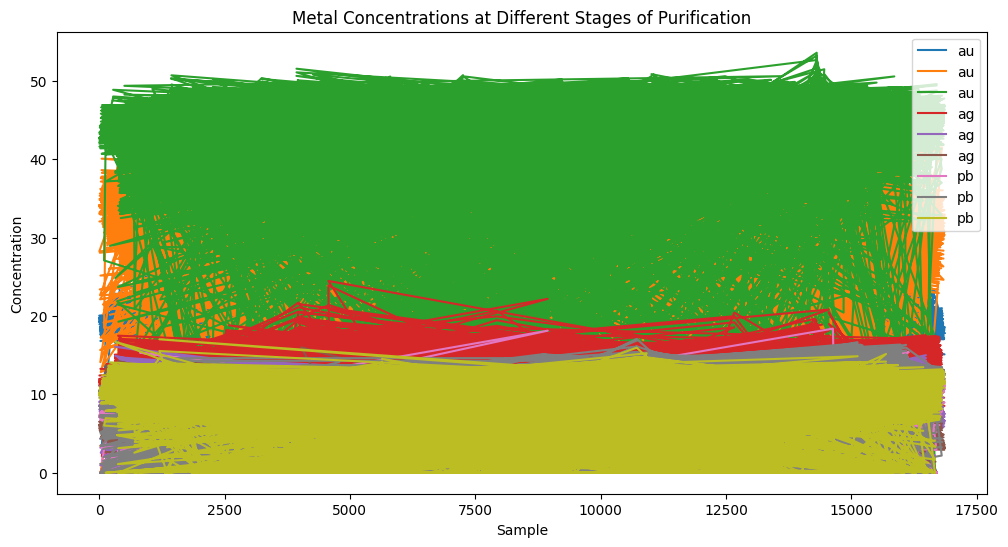

,rougher.output.concentrate_au,primary_cleaner.output.concentrate_au,final.output.concentrate_au,rougher.output.concentrate_ag,primary_cleaner.output.concentrate_ag,final.output.concentrate_ag,rougher.output.concentrate_pb,primary_cleaner.output.concentrate_pb,final.output.concentrate_pb
count,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000
mean,19.038567,31.790543,43.066546,11.574547,8.093580,5.135712,7.527191,9.396215,9.937241
std,4.619713,6.964135,7.590128,3.194726,2.262124,1.608178,2.130036,2.927425,2.090832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.225274,30.569042,42.992731,10.393427,7.023613,4.190150,6.760052,8.109148,9.218665
50%,19.896834,33.055134,44.770122,11.723753,8.210038,5.009670,7.733322,9.871476,10.238257
75%,21.414906,35.230406,46.120557,13.476727,9.538297,5.911288,8.600268,11.268259,11.142131
max,28.522811,45.933934,53.611374,24.480271,16.081632,16.001945,18.394042,17.081278,17.031899


In [22]:
# Defining the features based on available columns
features = [
    'rougher.output.concentrate_au', 
    'primary_cleaner.output.concentrate_au',
    'final.output.concentrate_au',
    'rougher.output.concentrate_ag', 
    'primary_cleaner.output.concentrate_ag',
    'final.output.concentrate_ag',
    'rougher.output.concentrate_pb', 
    'primary_cleaner.output.concentrate_pb',
    'final.output.concentrate_pb'
]

# Creating a new DataFrame with only the relevant features
concentration_data = train_df[features]

# Plotting and summary statistics:
plt.figure(figsize=(12, 6))
for metal in ['au', 'ag', 'pb']:
        plt.plot(concentration_data[[f'rougher.output.concentrate_{metal}', 
                                       f'primary_cleaner.output.concentrate_{metal}', 
                                       f'final.output.concentrate_{metal}']],
                 label=metal)
    
plt.title('Metal Concentrations at Different Stages of Purification')
plt.xlabel('Sample')
plt.ylabel('Concentration')
plt.legend()
plt.show()

summary_stats = concentration_data[features].describe()
display(summary_stats)


#### Conclusion for Analyzing and comparing Stats at Different Stages

Count: 

The count of 15,293 observations indicates a sizable dataset, which can provide reliable statistical analysis.

Mean:

The mean gold (Au) concentration increases from the rougher stage (19.04%) to the primary cleaner (31.79%) and final output (43.07%), indicating an effective purification process.
The mean silver (Ag) concentration decreases from the rougher stage (11.57%) to the primary cleaner (8.09%) and final output (5.14%), suggesting a loss of silver during the purification.
The mean lead (Pb) concentration increases slightly from the rougher stage (7.53%) to the primary cleaner (9.40%) and final output (9.94%), indicating a moderate increase in lead concentration.

Standard Deviation (Std):

The standard deviations for all metal concentrations are relatively low, indicating consistent performance of the mineral processing stages.
The standard deviations are higher for the rougher and primary cleaner stages compared to the final output, suggesting more variability in the earlier stages.

Percentiles:

25th Percentile (P25): 

Rougher stage P25: 18.23% - 25% of the rougher stage gold concentrations are below 18.23%.
Primary Cleaner stage P25: 30.57% - 25% of the primary cleaner stage gold concentrations are below 30.57%.
Final Output stage P25: 42.99% - 25% of the final output gold concentrations are below 42.99%.


Median:

Rougher stage Median: 19.90% - Half of the rougher stage gold concentrations are below 19.90%.
Primary Cleaner stage Median: 33.06% - Half of the primary cleaner stage gold concentrations are below 33.06%.
Final Output stage Median: 44.77% - Half of the final output gold concentrations are below 44.77%.


75th Percentile (P75):

Rougher stage P75: 21.41% - 75% of the rougher stage gold concentrations are below 21.41%.
Primary Cleaner stage P75: 35.23% - 75% of the primary cleaner stage gold concentrations are below 35.23%.
Final Output stage P75: 46.12% - 75% of the final output gold concentrations are below 46.12%.

The increase of gold concentration from rougher stage and final stage represents a positive outcome.

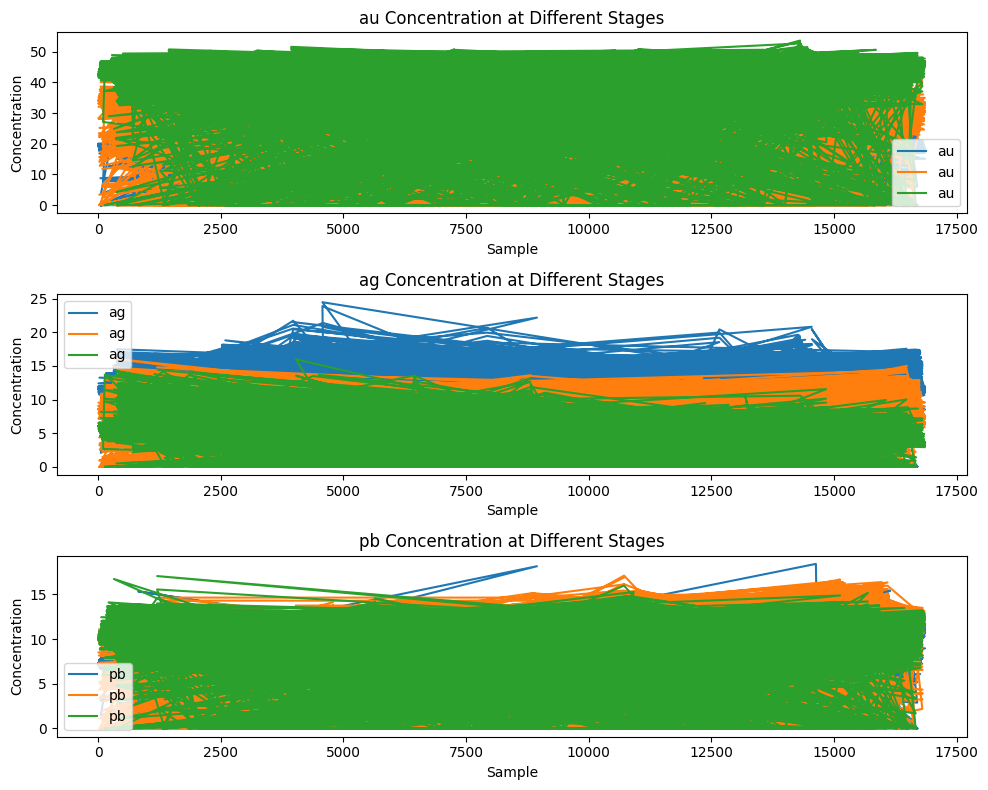

In [23]:
# Creating subplots for each metal:
metals = ['au', 'ag', 'pb'] 

fig, axes = plt.subplots(nrows=len(metals), ncols=1, figsize=(10, 8))

# Looping through each metal and create a plot
for i, metal in enumerate(metals):
    axes[i].plot(concentration_data[[f'rougher.output.concentrate_{metal}', 
                                       f'primary_cleaner.output.concentrate_{metal}', 
                                       f'final.output.concentrate_{metal}']],
                 label=metal)
    axes[i].set_title(f'{metal} Concentration at Different Stages')
    axes[i].set_xlabel('Sample')
    axes[i].set_ylabel('Concentration')
    axes[i].legend()
plt.tight_layout()
plt.show()

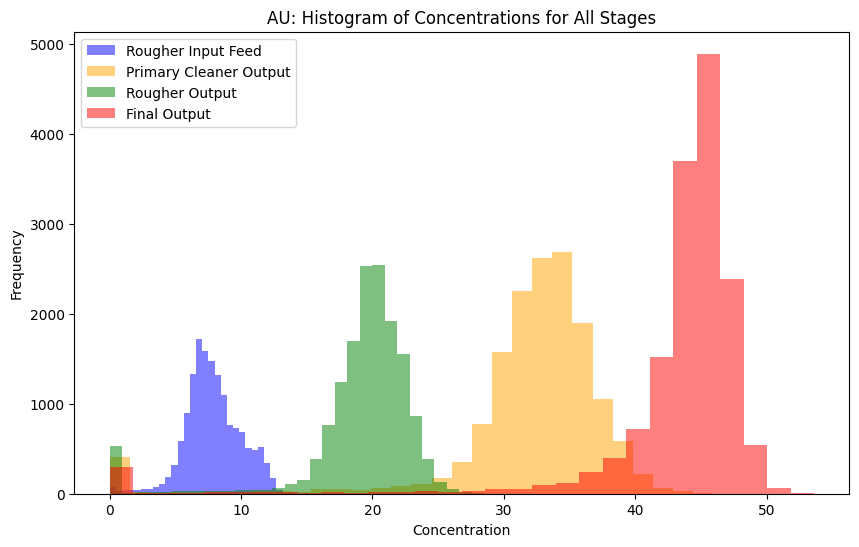

In [24]:
# Defining AU columns, stages, and colors
au_columns = [
    'rougher.input.feed_au',
    'primary_cleaner.output.concentrate_au',
    'rougher.output.concentrate_au',
    'final.output.concentrate_au'
]
stages = ['Rougher Input Feed', 'Primary Cleaner Output', 'Rougher Output', 'Final Output']
colors = ['blue', 'orange', 'green', 'red']

# Creating the histogram
plt.figure(figsize=(10, 6))

# Looping through each column to plot histograms
for j, column in enumerate(au_columns):
    plt.hist(train_df[column], bins=30, color=colors[j], alpha=0.5, label=stages[j])

# Adding titles and labels
plt.title('AU: Histogram of Concentrations for All Stages')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()  # Show legend to identify stages
plt.show()


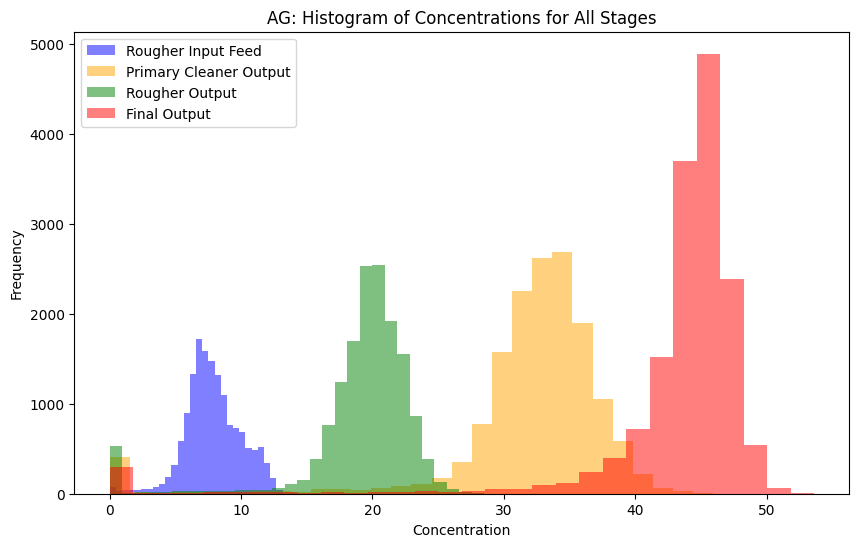

In [25]:
# Defining AG columns, stages, and colors
ag_columns = [
    'rougher.input.feed_ag',
    'primary_cleaner.output.concentrate_ag',
    'rougher.output.concentrate_ag',
    'final.output.concentrate_ag'
]
stages = ['Rougher Input Feed', 'Primary Cleaner Output', 'Rougher Output', 'Final Output']
colors = ['blue', 'orange', 'green', 'red']

# Creating histogram:
plt.figure(figsize=(10, 6))

# Looping through each column to plot histograms
for j, column in enumerate(au_columns):
    plt.hist(train_df[column], bins=30, color=colors[j], alpha=0.5, label=stages[j])

# Adding titles and labels
plt.title('AG: Histogram of Concentrations for All Stages')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()  # Show legend to identify stages
plt.show()


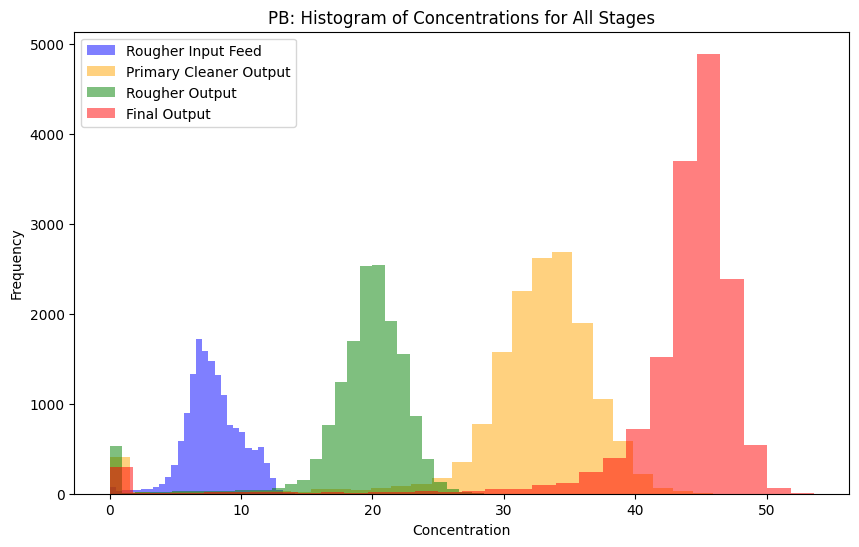

In [26]:
# Defining PB columns, stages, and colors
pb_columns = [
    'rougher.input.feed_pb',
    'primary_cleaner.output.concentrate_pb',
    'rougher.output.concentrate_pb',
    'final.output.concentrate_pb'
]
stages = ['Rougher Input Feed', 'Primary Cleaner Output', 'Rougher Output', 'Final Output']
colors = ['blue', 'orange', 'green', 'red']

# Creating histogram:
plt.figure(figsize=(10, 6))

# Looping through each column to plot histograms
for j, column in enumerate(au_columns):
    plt.hist(train_df[column], bins=30, color=colors[j], alpha=0.5, label=stages[j])

# Adding titles and labels
plt.title('PB: Histogram of Concentrations for All Stages')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()  # Show legend to identify stages
plt.show()


<span style="color: blue;">
    
## 2.2. Comparing the feed particle size distributions in the training set and in the test set. If the distributions vary significantly, the model evaluation will be incorrect.

</span>

### 2.2.1. Looking for columns that might contain particle size data.

In [27]:
keyword = 'size'
matching_columns = train_df.columns[train_df.columns.str.contains(keyword, case=False)]

print(matching_columns)

keyword = 'size'
matching_columns = test_df.columns[test_df.columns.str.contains(keyword, case=False)]

print(matching_columns)

Index(['primary_cleaner.input.feed_size', 'rougher.input.feed_size'], dtype='object')
Index(['primary_cleaner.input.feed_size', 'rougher.input.feed_size'], dtype='object')


### 2.2.2. Extracting Feed Sizes and Ploting

Original Code:

train_feed_size = train_df[['primary_cleaner.input.feed_size', 'rougher.input.feed_size']]
test_feed_size = test_df[['primary_cleaner.input.feed_size', 'rougher.input.feed_size']]

print(train_feed_size)
print(test_feed_size )

plt.figure(figsize=(12, 12))  
plt.subplot(2, 1, 1) 
plt.hist(train_feed_size['primary_cleaner.input.feed_size'], bins=30, label='Primary Cleaner Feed Size (Train)')
plt.hist(train_feed_size['rougher.input.feed_size'], bins=30, label='Rougher Feed Size (Train)')
plt.title('Training Set Feed Size Distribution')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 1, 2)  
plt.hist(test_feed_size['primary_cleaner.input.feed_size'], bins=30, label='Primary Cleaner Feed Size (Test)')
plt.hist(test_feed_size['rougher.input.feed_size'], bins=30, label='Rougher Feed Size (Test)')
plt.title('Test Set Feed Size Distribution')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()


       primary_cleaner.input.feed_size
12567                         7.500000
13189                         6.410000
13478                         7.510000
13521                         7.510000
13479                         7.510000
...                                ...
9121                          6.840000
9122                          6.840000
9116                          6.650001
9119                          7.170000
9118                          6.650000

[15293 rows x 1 columns]
                     primary_cleaner.input.feed_size
date                                                
2016-09-01 00:59:59                         8.080000
2016-09-01 01:59:59                         8.080000
2016-09-01 02:59:59                         7.786667
2016-09-01 03:59:59                         7.640000
2016-09-01 04:59:59                         7.530000
...                                              ...
2017-12-31 19:59:59                         8.070000
2017-12-31 20:59:59          

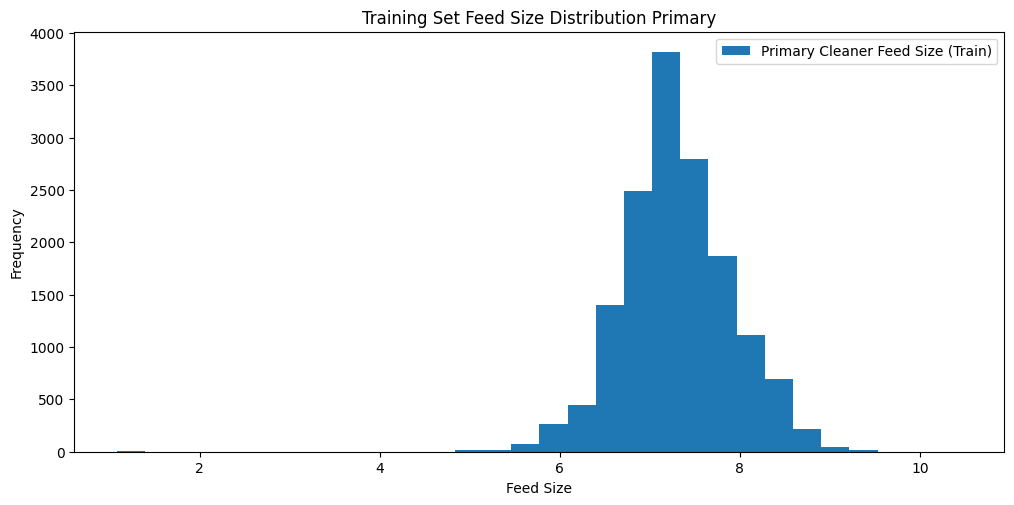

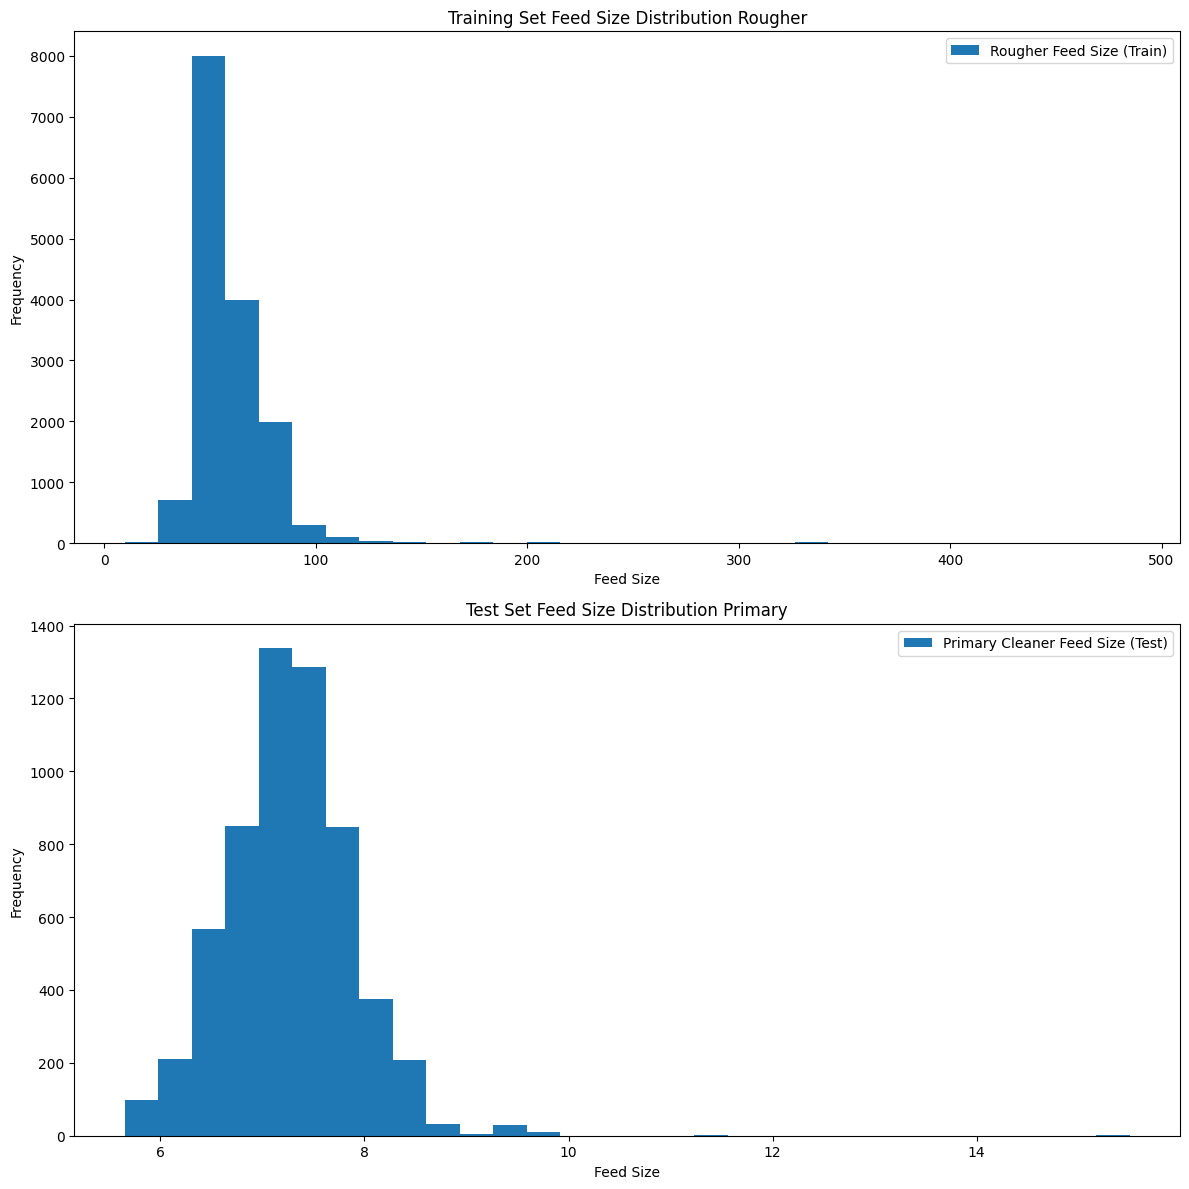

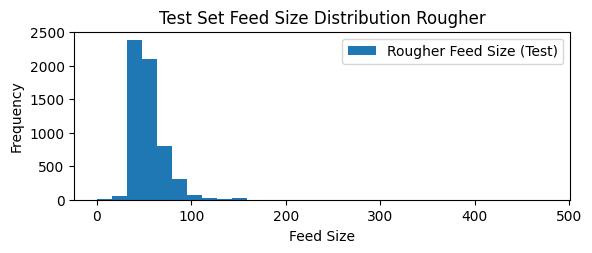

In [28]:
# Corrected code:

train_feed_size_primary = train_df[['primary_cleaner.input.feed_size']]
test_feed_size_primary = test_df[['primary_cleaner.input.feed_size']]

train_feed_size_rougher = train_df[['rougher.input.feed_size']]
test_feed_size_rougher = test_df[['rougher.input.feed_size']]


print(train_feed_size_primary)
print(test_feed_size_primary)

print(train_feed_size_rougher)
print(test_feed_size_rougher)

plt.figure(figsize=(12, 12))  
plt.subplot(2, 1, 1) 
plt.hist(train_feed_size_primary['primary_cleaner.input.feed_size'], bins=30, label='Primary Cleaner Feed Size (Train)')
plt.title('Training Set Feed Size Distribution Primary')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()

plt.figure(figsize=(12, 12))  
plt.subplot(2, 1, 1) 
plt.hist(train_feed_size_rougher['rougher.input.feed_size'], bins=30, label='Rougher Feed Size (Train)')
plt.title('Training Set Feed Size Distribution Rougher')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 1, 2)  
plt.hist(test_feed_size_primary['primary_cleaner.input.feed_size'], bins=30, label='Primary Cleaner Feed Size (Test)')
plt.title('Test Set Feed Size Distribution Primary')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

plt.subplot(2, 1, 2)  
plt.hist(test_feed_size_rougher['rougher.input.feed_size'], bins=30, label='Rougher Feed Size (Test)')
plt.title('Test Set Feed Size Distribution Rougher')
plt.xlabel('Feed Size')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<span style="color: blue;">
    
## 2.3. Considering the total concentrations of all substances at different stages: raw feed, rougher concentrate, and final concentrate. Looking for abnormal values in the total distribution. Describing and eliminating anomalies

</span>

### 2.3.1. Total Concentrations at different stages for full_df

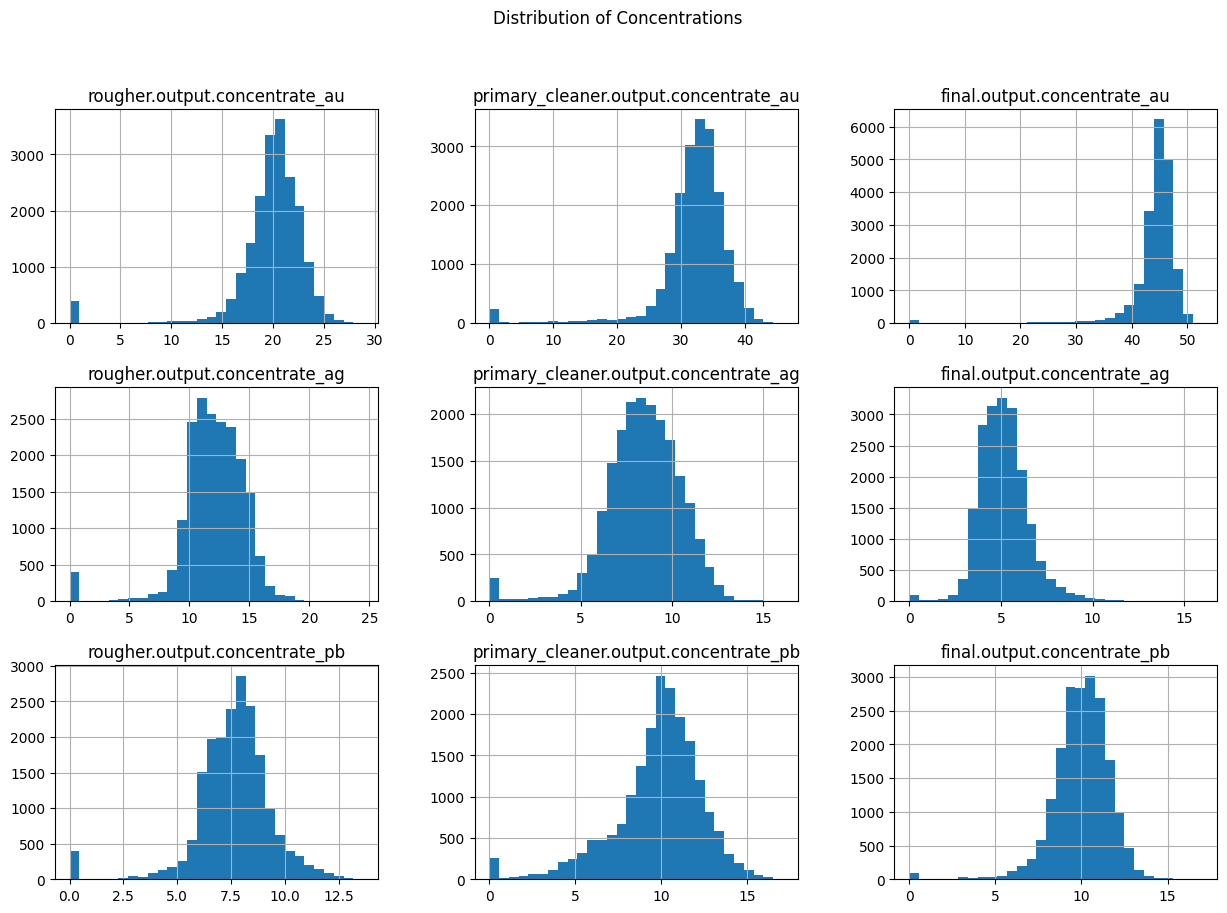

Original Data Size: (19439, 9)
Filtered Data Size: (16144, 9)


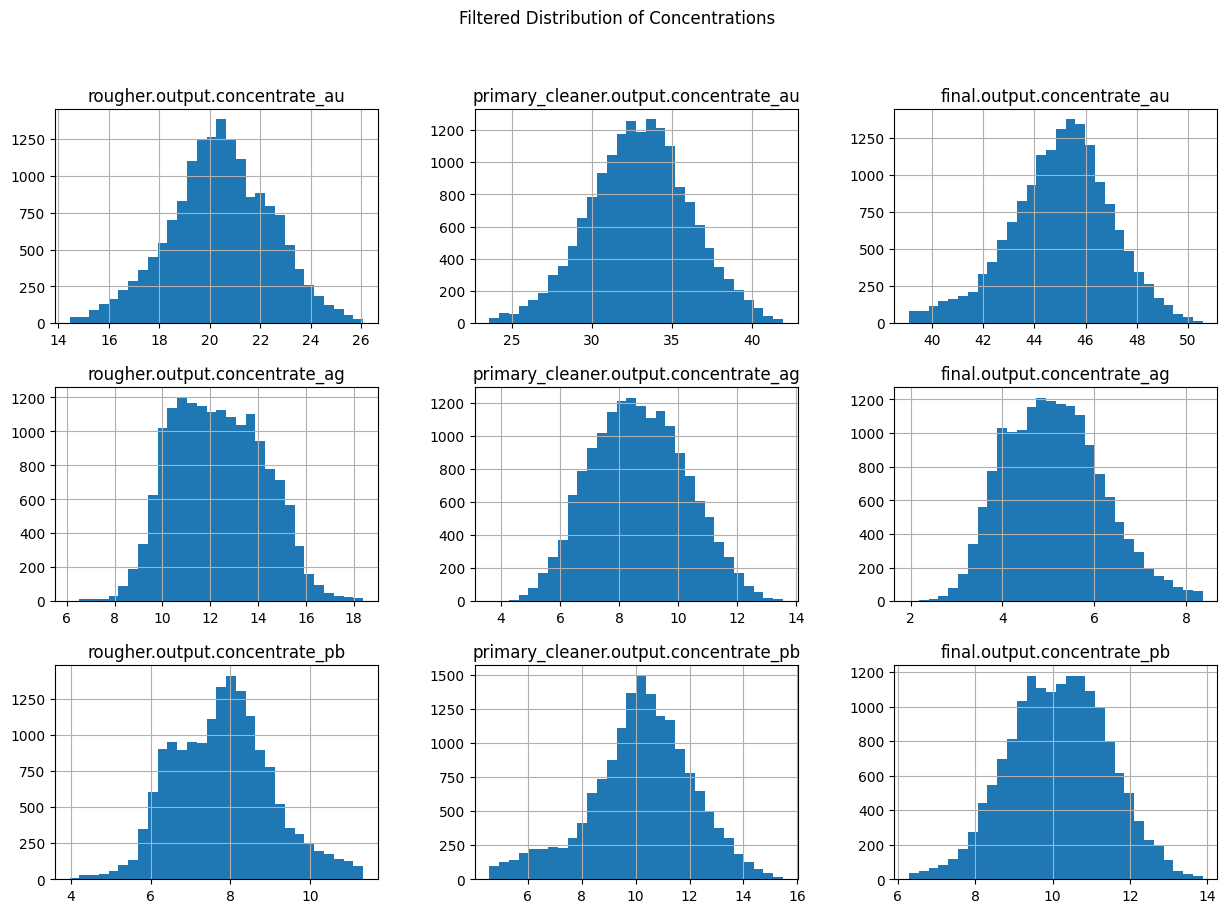

,rougher.output.concentrate_au,primary_cleaner.output.concentrate_au,final.output.concentrate_au,rougher.output.concentrate_ag,primary_cleaner.output.concentrate_ag,final.output.concentrate_ag,rougher.output.concentrate_pb,primary_cleaner.output.concentrate_pb,final.output.concentrate_pb
count,19439.000000,19439.000000,19439.000000,19439.000000,19439.000000,19439.000000,19439.000000,19439.000000,19439.000000
mean,19.772000,32.119400,44.076513,11.994759,8.442408,5.168387,7.606272,9.810317,9.978821
std,3.753600,5.627611,5.129784,2.733862,2.054465,1.372362,1.796757,2.572253,1.669228
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.802523,30.463140,43.402215,10.628337,7.263288,4.251000,6.725987,8.676500,9.137225
50%,20.280214,32.841295,45.011244,12.098115,8.507298,5.066039,7.742580,10.142270,10.102264
75%,21.717843,35.048006,46.275313,13.736996,9.809001,5.895401,8.565199,11.416298,11.035644
max,28.824507,45.933934,52.756638,24.480271,16.081632,16.001945,13.617072,17.081278,17.031899


In [29]:
# Combine relevant features into a single DataFrame
{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'predicted_recovery',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.tail_pb',
 'rougher.output.tail_sol',
 'secondary_cleaner.output.tail_ag',
 'secondary_cleaner.output.tail_au',
 'secondary_cleaner.output.tail_pb',
 'secondary_cleaner.output.tail_sol'}

concentrations_full_df = full_df[features]

# Visualizing distributions
concentrations_full_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Concentrations')
plt.show()

# Identifying and remove anomalies using IQR
Q1 = concentrations_full_df.quantile(0.25)
Q3 = concentrations_full_df.quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers
filtered_full_df = concentrations_full_df[~((concentrations_full_df < (Q1 - 1.5 * IQR)) | (concentrations_full_df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Findings
print(f"Original Data Size: {concentrations_full_df.shape}")
print(f"Filtered Data Size: {filtered_full_df.shape}")

# Vizualization of filtered data
filtered_full_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Filtered Distribution of Concentrations')
plt.show()

# Calculating descriptive statistics
stats = concentrations_full_df.describe()
display(stats)


### 2.3.2. Total Concentrations at different stages for train_df

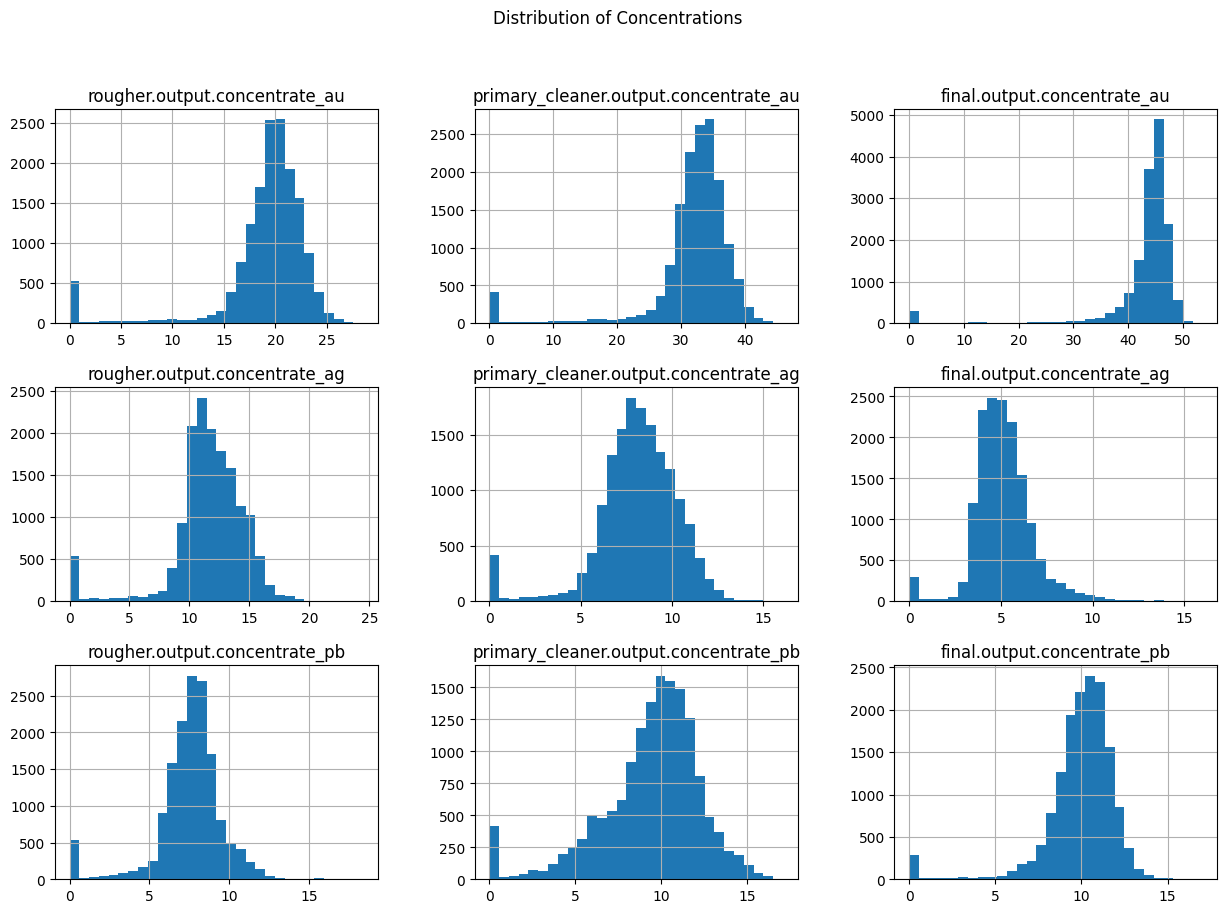

Original Data Size: (15293, 9)
Filtered Data Size: (12208, 9)


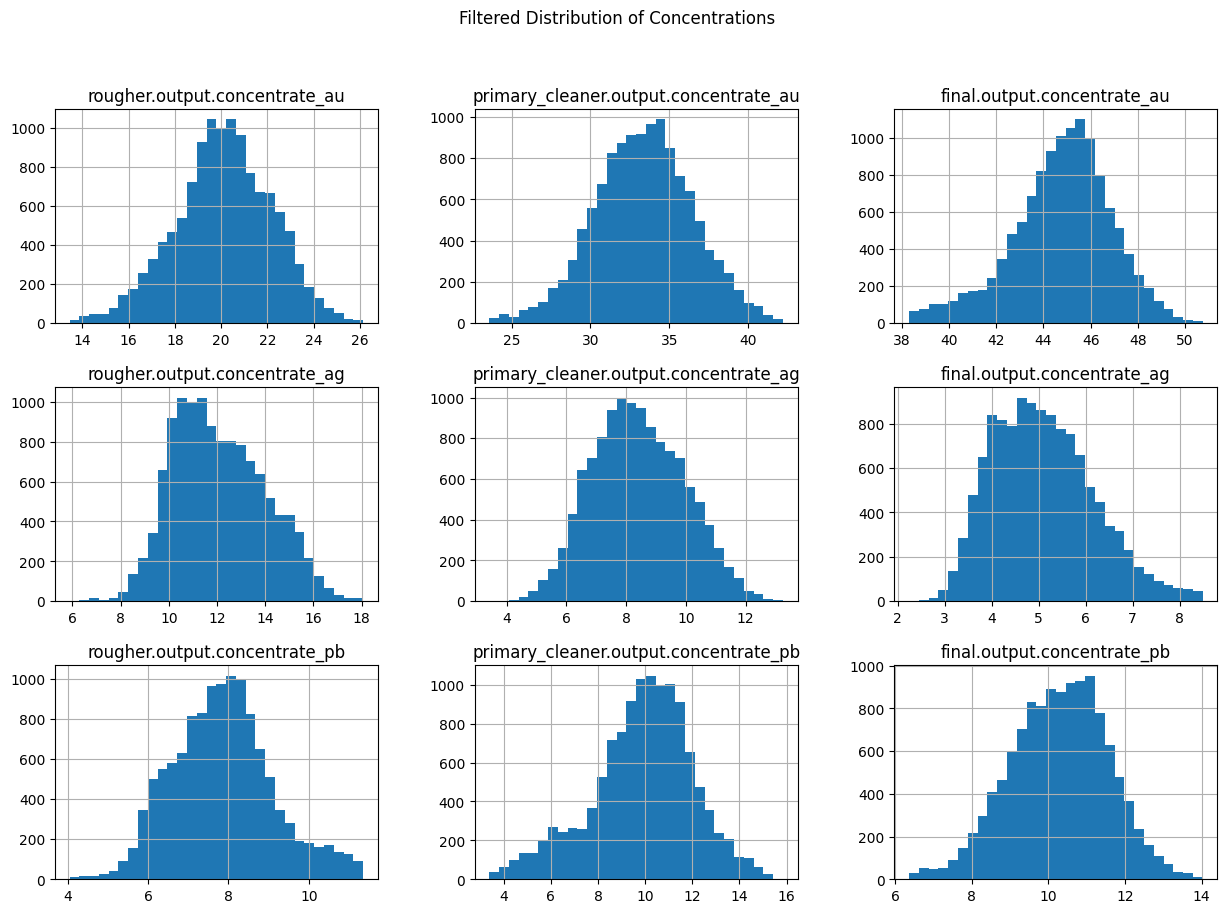

,rougher.output.concentrate_au,primary_cleaner.output.concentrate_au,final.output.concentrate_au,rougher.output.concentrate_ag,primary_cleaner.output.concentrate_ag,final.output.concentrate_ag,rougher.output.concentrate_pb,primary_cleaner.output.concentrate_pb,final.output.concentrate_pb
count,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000,15293.000000
mean,19.038567,31.790543,43.066546,11.574547,8.093580,5.135712,7.527191,9.396215,9.937241
std,4.619713,6.964135,7.590128,3.194726,2.262124,1.608178,2.130036,2.927425,2.090832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.225274,30.569042,42.992731,10.393427,7.023613,4.190150,6.760052,8.109148,9.218665
50%,19.896834,33.055134,44.770122,11.723753,8.210038,5.009670,7.733322,9.871476,10.238257
75%,21.414906,35.230406,46.120557,13.476727,9.538297,5.911288,8.600268,11.268259,11.142131
max,28.522811,45.933934,53.611374,24.480271,16.081632,16.001945,18.394042,17.081278,17.031899


In [30]:
# Combining relevant features into a single DataFrame
{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'predicted_recovery',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.tail_pb',
 'rougher.output.tail_sol',
 'secondary_cleaner.output.tail_ag',
 'secondary_cleaner.output.tail_au',
 'secondary_cleaner.output.tail_pb',
 'secondary_cleaner.output.tail_sol'}

concentrations_train_df = train_df[features]

# Visualizing distributions
concentrations_train_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Concentrations')
plt.show()

# Identifying and remove anomalies using IQR
Q1 = concentrations_train_df.quantile(0.25)
Q3 = concentrations_train_df.quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers
filtered_train_df = concentrations_train_df[~((concentrations_train_df < (Q1 - 1.5 * IQR)) | (concentrations_train_df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Findings
print(f"Original Data Size: {concentrations_train_df.shape}")
print(f"Filtered Data Size: {filtered_train_df.shape}")

# Vizualization of filtered data
filtered_train_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Filtered Distribution of Concentrations')
plt.show()

# Calculating descriptive statistics
stats = concentrations_train_df.describe()
display(stats)


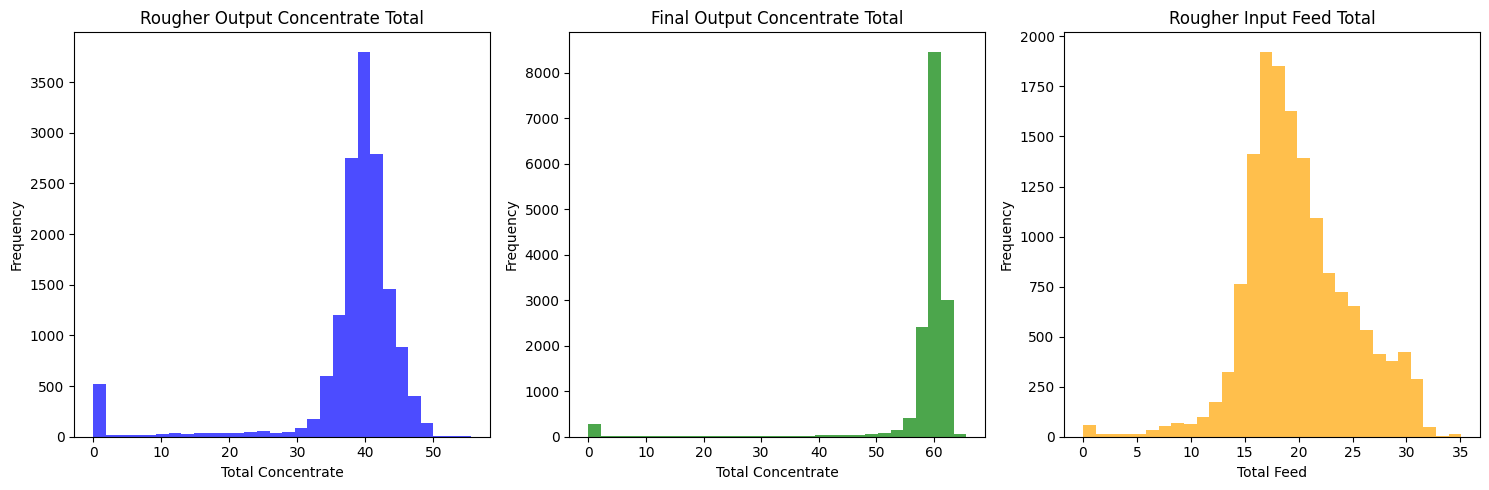

In [31]:
train_df['rougher.output.concentrate_total'] = train_df[['rougher.output.concentrate_au', 
                                               'rougher.output.concentrate_ag', 
                                               'rougher.output.concentrate_pb']].sum(axis=1)

train_df['final.output.concentrate_total'] = train_df[['final.output.concentrate_au', 
                                             'final.output.concentrate_ag', 
                                             'final.output.concentrate_pb']].sum(axis=1)

train_df['rougher.input.feed_total'] = train_df[['rougher.input.feed_au', 
                                       'rougher.input.feed_ag', 
                                       'rougher.input.feed_pb']].sum(axis=1)

# Plotting histograms
plt.figure(figsize=(15, 5))

# Rougher Output Concentrate Histogram
plt.subplot(1, 3, 1)
plt.hist(train_df['rougher.output.concentrate_total'], bins=30, color='blue', alpha=0.7)
plt.title('Rougher Output Concentrate Total')
plt.xlabel('Total Concentrate')
plt.ylabel('Frequency')

# Final Output Concentrate Histogram
plt.subplot(1, 3, 2)
plt.hist(train_df['final.output.concentrate_total'], bins=30, color='green', alpha=0.7)
plt.title('Final Output Concentrate Total')
plt.xlabel('Total Concentrate')
plt.ylabel('Frequency')

# Rougher Input Feed Histogram
plt.subplot(1, 3, 3)
plt.hist(train_df['rougher.input.feed_total'], bins=30, color='orange', alpha=0.7)
plt.title('Rougher Input Feed Total')
plt.xlabel('Total Feed')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 2.3.1. Total Concentrations at different stages for test_df

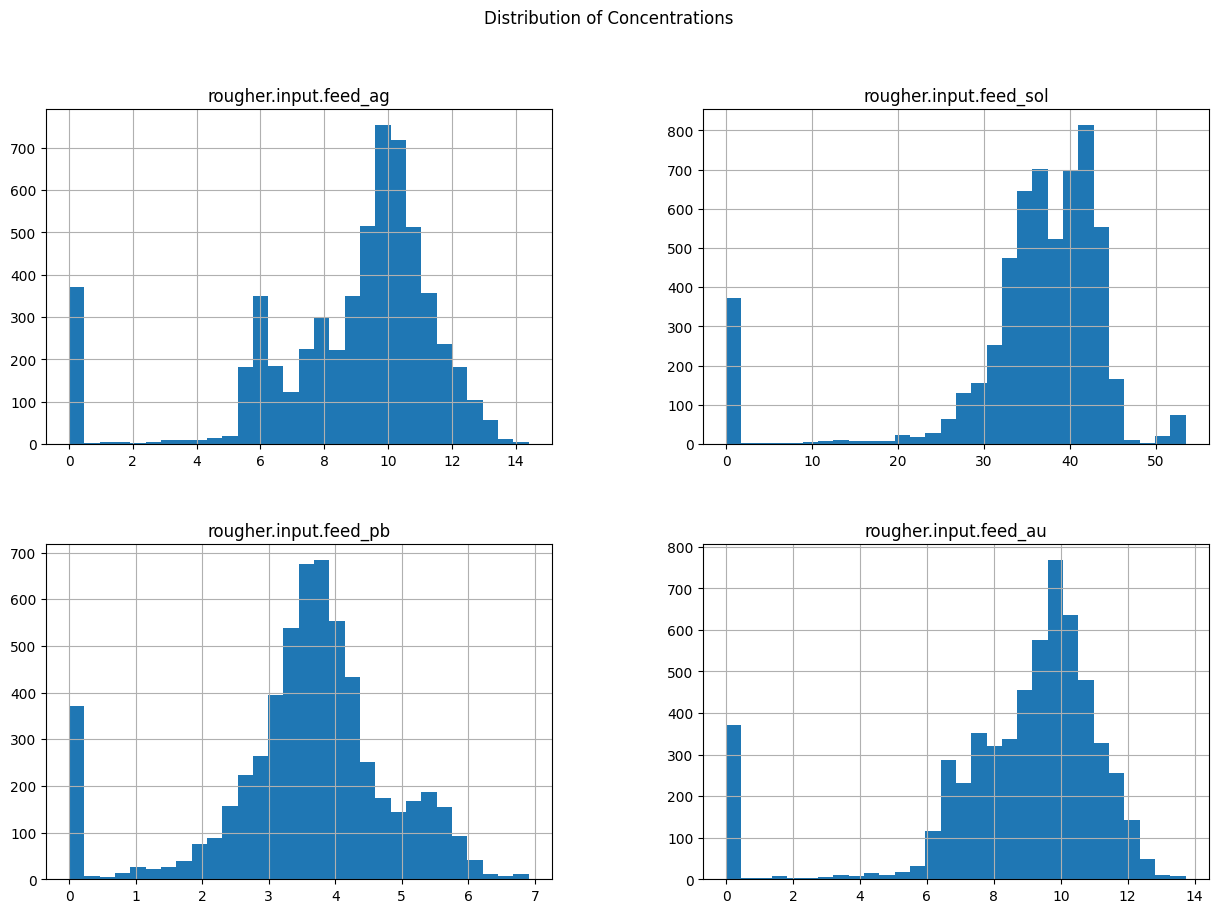

Original Data Size: (5856, 4)
Filtered Data Size: (5280, 4)


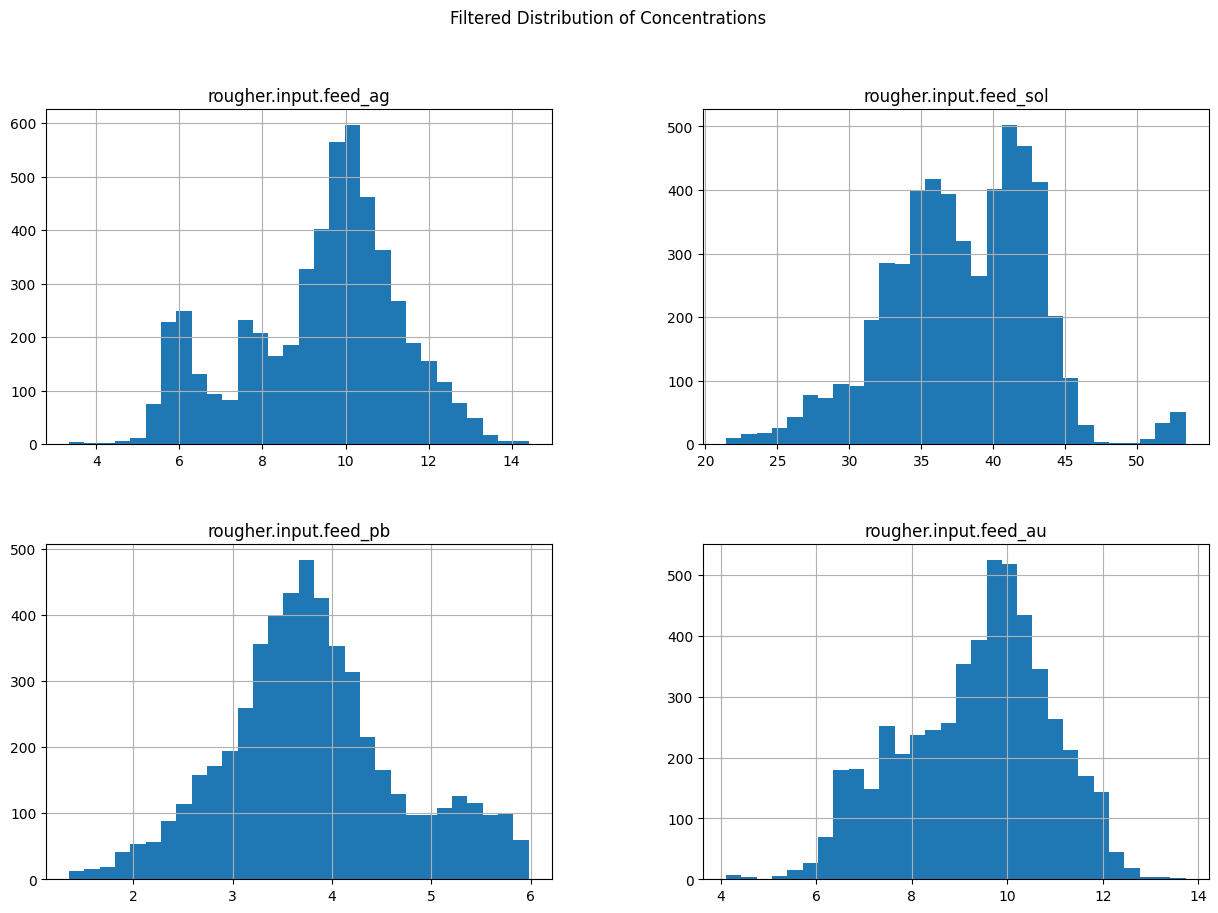

,rougher.input.feed_ag,rougher.input.feed_sol,rougher.input.feed_pb,rougher.input.feed_au
count,5840.000000,5789.000000,5840.000000,5840.000000
mean,8.736170,35.105834,3.552722,8.700930
std,2.985805,10.793249,1.326113,2.803046
min,0.000000,0.000000,0.000000,0.000000
25%,7.598683,33.381580,3.079145,7.763634
50%,9.628324,37.336634,3.679706,9.449623
75%,10.568373,41.388612,4.241195,10.377337
max,14.406130,53.477742,6.905684,13.731330


In [32]:
# Combining relevant features into a single DataFrame:
features = {'rougher.input.feed_ag',
 'rougher.input.feed_pb',                     
 'rougher.input.feed_sol',                     
 'rougher.input.feed_au'}

concentrations_test_df = test_df[features]

# Visualizing distributions
concentrations_test_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Concentrations')
plt.show()

# Identifying and remove anomalies using IQR
Q1 = concentrations_test_df.quantile(0.25)
Q3 = concentrations_test_df.quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers
filtered_test_df = concentrations_test_df[~((concentrations_test_df < (Q1 - 1.5 * IQR)) | (concentrations_test_df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Findings
print(f"Original Data Size: {concentrations_test_df.shape}")
print(f"Filtered Data Size: {filtered_test_df.shape}")

# Vizualization of filtered data
filtered_test_df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Filtered Distribution of Concentrations')
plt.show()

# Calculating descriptive statistics
stats = concentrations_test_df.describe()
display(stats)


<span style="color: blue;">
    
# 3. Building the Model

</span>

<span style="color: blue;">
    
## 3.1. Writing a function to calculate the final sMAPE value.

</span>

In [33]:

def final_smape (target, prediction):
    '''
    prediction is split into rougher prediction(RP) and final prediction(FP).
    target is split into rougher target(RT) and final target(FT).
    
    RT is the value of target for the observation in the sample used to measure quality 
    of the rougher output - ROUGHER TARGET.
    RP is the value of prediction for the observation of the rougher output - ROUGHER PREDICTION.
    FT is the value of target for the observation in the sample used to measure 
    quality of the final output FINAL TARGET. 
    FP is the value of prediction for the observation of the final output FINAL PREDICTION.
    '''
    RT, FT = target.iloc[:, 0], target.iloc[:, 1]

    # RT, FT = target[:, 0], target[:, 1]
    RP, FP = prediction[:,0], prediction[:,1]
    
    ro_smape = (1/len(RT)) * sum(abs(RT - RP) / ((abs(RT) + abs(RP)) / 2) * 100)
    fo_smape = (1/len(FT)) * sum(abs(FT - FP) / ((abs(FT) + abs(FP)) / 2) * 100)
    final_smape = (.25 * ro_smape) + (.75 * fo_smape)
    
    return final_smape

<span style="color: blue;">
    
## 3.2. Determining features and targets for model fitting

</span>

#### Reviewer's Comment: Dataframes without outliers

#### Student's Comment: I did not know how to use the dataframes without outliers because the dataframes without outliesrs that I used for the histograms have only 4 features features = {'rougher.input.feed_ag','rougher.input.feed_pb', 'rougher.input.feed_sol', 'rougher.input.feed_au'} as per project requirement.

In [34]:
# Creating features_train
features = test_df.columns.values
features_train = train_df[features].reset_index(drop=True)

# Creating target_train
target_train = full_df[['rougher.output.recovery', 'final.output.recovery']].reset_index(drop=True) 

# Checking shapes
print("Features shape:", features_train.shape)
print("Target shape:", target_train.shape)

# Ensuring both DataFrames have the same number of rows
min_length = min(features_train.shape[0], target_train.shape[0])
features_train = features_train.iloc[:min_length]
target_train = target_train.iloc[:min_length]

#Checking Shapes
print("Features shape:", features_train.shape)
print("Target shape:", target_train.shape)

Features shape: (15293, 52)
Target shape: (19439, 2)
Features shape: (15293, 52)
Target shape: (15293, 2)


In [35]:
# train set:
# same_dates = train_df['date'].isin(full_df['date'])
# features = test_df.columns
# features_train = train_df.loc[list(set(full_df.index).intersection((set(train_df.index)))) , features] #.reset_index(drop=True)
# target_train = train_df.loc [list(set(full_df.index).intersection((set(train_df.index)))) , ['rougher.output.recovery', 'final.output.recovery']]  #.reset_index(drop=True)

# test set

#features_test = test_df.loc[list(set(full_df.index).intersection((set(test_df.index))))]
# target_test = full_df.loc[list(set(full_df.index).intersection((set(test_df.index)))), ['rougher.output.recovery', 'final.output.recovery'] ]  # full_df.loc[test_df.index , 'rougher.output.recovery', 'final.output.recovery']'''

<span style="color: blue;">
    
## 3.3. Training different models. Evaluating them using cross-validation. Picking the best model and test it using the test sample. Providing findings.

</span>

### 3.3.1. Dummy Regressor

In [36]:
# Turning the function into a cross validation scorer
smape_scorer = make_scorer(final_smape)
# Fitting the model:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(features_train, target_train)
scores = cross_val_score(dummy_regr, features_train, target_train, cv=5, scoring=smape_scorer)
dummy_score = sum(scores) / len(scores)
print("Baseline sMAPE value:", dummy_score)

Baseline sMAPE value: 11.275930204743503


### 3.3.2. Decision Tree Regressor

In [37]:
dtr_model = None
best_score = 100
best_depth = 0
for depth in range(1, 15):
    model = DecisionTreeRegressor(max_depth=depth, random_state=12345)
    model.fit(features_train, target_train)
    scores = cross_val_score(model, features_train, target_train, cv=5, scoring=smape_scorer)
    cv_score = sum(scores) / len(scores)
    if abs(cv_score) < abs(best_score):
        dtr_model = model
        best_score = cv_score
        best_depth = depth
dtr_model = DecisionTreeRegressor(max_depth=best_depth, random_state=12345)
dtr_model.fit(features_train, target_train)

print("Best Depth:", best_depth)
print("Highest Average Cross Validation Score:", best_score)

Best Depth: 4
Highest Average Cross Validation Score: 11.64340069283627


### 3.3.3 Random Forest

In [38]:
rfr_model = None
best_score = 100
best_est = 0
best_depth = 0
for est in range(20, 40, 10):
    for depth in range (4, 10):
        model = RandomForestRegressor(random_state=759638, n_estimators=est, max_depth=depth)
        model.fit(features_train, target_train)
        scores = cross_val_score(model, features_train, target_train, cv=5, scoring=smape_scorer)
        cv_score = sum(scores) / len(scores)
        if abs(cv_score) < abs(best_score):
            rfr_model = model
            best_score = cv_score
            best_est = est
            best_depth = depth
rfr_model = RandomForestRegressor(random_state=759638, n_estimators=best_est, max_depth=best_depth)
rfr_model.fit(features_train, target_train)

print("Best Estimators:", best_est)
print("Best Depth:", best_depth)
print("Highest Average Cross Validation Score:", best_score)

Best Estimators: 30
Best Depth: 7
Highest Average Cross Validation Score: 11.53638920628249


### 3.3.4. Linear Regressiom

In [39]:
lr_model = LinearRegression()
lr_model.fit(features_train, target_train)

scores = cross_val_score(lr_model, features_train, target_train, cv=5, scoring=smape_scorer)
final_score = sum(scores) / len(scores)

print('Average Cross Validation Score:', final_score)

Average Cross Validation Score: 11.91088690477786


#### The Random Forest Regressor achieves the highest Average Cross Validation Score of 11.53638920628249, outperforming the other models.

In [40]:
features_test = pd.DataFrame(test_df)
target_test = full_df[['rougher.output.recovery', 'final.output.recovery'] ]

# Checking shapes
print("Features shape:", features_test.shape)
print("Target shape:", target_test.shape)

# Ensuring both DataFrames have the same number of rows
min_length = min(features_test.shape[0], target_test.shape[0])
features_test = features_test.iloc[:min_length]
target_test = target_test.iloc[:min_length]

#Checking Shapes
print("Features shape:", features_test.shape)
print("Target shape:", target_test.shape)


Features shape: (5856, 52)
Target shape: (19439, 2)
Features shape: (5856, 52)
Target shape: (5856, 2)


In [41]:
features_test.info()
target_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2016-09-01 00:59:59 to 2017-12-31 23:59:59
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               5554 non-null   float64
 1   primary_cleaner.input.depressant            5572 non-null   float64
 2   primary_cleaner.input.feed_size             5856 non-null   float64
 3   primary_cleaner.input.xanthate              5690 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    5840 

In [42]:
features_test.fillna(method = 'ffill', inplace = True)
target_test.fillna(method = 'ffill' , inplace = True)
features_test.info()
target_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2016-09-01 00:59:59 to 2017-12-31 23:59:59
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               5856 non-null   float64
 1   primary_cleaner.input.depressant            5856 non-null   float64
 2   primary_cleaner.input.feed_size             5856 non-null   float64
 3   primary_cleaner.input.xanthate              5856 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      5856 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    5856 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      5856 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    5856 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      5856 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    5856 

In [43]:
best_model = rfr_model  
best_model.fit(features_train, target_train)

# Make predictions
predictions = best_model.predict(features_test)

# Calculate final sMAPE on the test set
final_score = final_smape(target_test, predictions)
print(f'Final sMAPE on Test Set: {final_score}')

Final sMAPE on Test Set: 12.080307381962903


# Conclusion: 

In this project, I developed a machine learning model to predict the recovery rate of gold from ore, utilizing various regression techniques. After careful consideration, I chose the Random Forest Regressor as the primary model due to its ability to handle complex relationships and interactions. This model demonstrated strong performance in terms of accuracy and robustness, making it suitable for the intricacies of gold recovery prediction.

The insights gained from the model will enable Zyfra's management to make data-driven decisions regarding operational adjustments. 